In [1]:
import pandas as pd
import numpy as np

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score

import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedShuffleSplit

In [ ]:
# RUNS_PER_M = 10
RUNS_PER_M = 1000

# global hyperparameter to set the number of iterations in the experiment per training set size m 
# for experimenting we used runs_per_m = 20, due to limited computing power

In [4]:
class MixedNaiveBayes:
    def __init__(self, data, X, Y, alpha=1.5):
        self.data = data
        self.X = X
        self.Y = Y
        self.alpha = alpha
        self.classes = data[Y].unique()

    def detect_feature_types(self):
        types = {}
        for feature in self.X:
            nunique = self.data[feature].nunique()

            if nunique == 2:
                types[feature] = "binary"
            elif nunique <= 20:
                types[feature] = "categorical"
            else:
                types[feature] = "continuous"

        return types

    def compute_priors(self):
        priors = {}
        total = len(self.data)

        for c in self.classes:
            priors[c] = (self.data[self.data[self.Y] == c].shape[0]) / total

        return priors

    def fit(self):
        self.feature_types = self.detect_feature_types()
        self.priors = self.compute_priors()

        self.cond_probs = {}
        self.gaussians = {}
        self.category_values = {}

        # Store all possible values for discrete features
        for feature in self.X:
            ftype = self.feature_types[feature]
            if ftype in ("binary", "categorical"):
                self.category_values[feature] = self.data[feature].unique().tolist()

        for c in self.classes:
            subset = self.data[self.data[self.Y] == c]

            self.cond_probs[c] = {}
            self.gaussians[c] = {}

            for feature in self.X:
                ftype = self.feature_types[feature]

                if ftype in ("binary", "categorical"):
                    values = self.category_values[feature]
                    counts = subset[feature].value_counts().to_dict()

                    total_count = len(subset)
                    K = len(values)
                    alpha = self.alpha
                    # add laplace smoothing to prevent zero conditional probability:
                    self.cond_probs[c][feature] = {
                        v: (counts.get(v, 0) + alpha) / (total_count + alpha * K)
                        for v in values
                    }

                elif ftype == "continuous":
                    mu = subset[feature].mean()
                    var = subset[feature].var(ddof=0) + 1e-9
                    self.gaussians[c][feature] = (mu, var)

    def gaussian_prob(self, x, mu, var):
        return (1 / np.sqrt(2 * np.pi * var)) * np.exp(-((x - mu) ** 2) / (2 * var))

    def predict_row(self, row):
        class_scores = {}

        for c in self.classes:
            score = np.log(self.priors[c] + 1e-12)

            for feature in self.X:
                ftype = self.feature_types[feature]
                value = row[feature]

                if ftype in ("binary", "categorical"):
                    prob = self.cond_probs[c][feature].get(value)

                    # If something weird slips through
                    if prob is None:
                        K = len(self.category_values[feature])
                        prob = 1.0 / max(1, K)

                    score += np.log(prob + 1e-12)

                else:  # continuous
                    mu, var = self.gaussians[c][feature]
                    score += np.log(self.gaussian_prob(value, mu, var) + 1e-12)

            class_scores[c] = score

        return max(class_scores, key=class_scores.get)

    def predict(self, X_df):
        return [self.predict_row(row) for _, row in X_df.iterrows()]


Voting Dataset

In [5]:
df_voting = pd.read_csv("voting.csv")
df_voting.describe()

,label,handicapped-infants,water-project-cost-sharing,adoption-of-the-budget-resolution,physician-fee-freeze,el-salvador-aid,religious-groups-in-schools,anti-satellite-test-ban,aid-to-nicaraguan-contras,mx-missile,immigration,synfuels-corporation-cutback,education-spending,superfund-right-to-sue,crime,duty-free-exports,export-administration-act-south-africa
count,435,423,387,424,424,420,424,421,420,413,428,414,404,410,418,407,331
unique,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2
top,democrat,n,y,y,n,y,y,y,y,y,y,n,n,y,y,n,y
freq,267,236,195,253,247,212,272,239,242,207,216,264,233,209,248,233,269


In [6]:
df_voting

,label,handicapped-infants,water-project-cost-sharing,adoption-of-the-budget-resolution,physician-fee-freeze,el-salvador-aid,religious-groups-in-schools,anti-satellite-test-ban,aid-to-nicaraguan-contras,mx-missile,immigration,synfuels-corporation-cutback,education-spending,superfund-right-to-sue,crime,duty-free-exports,export-administration-act-south-africa
0,republican,n,y,n,y,y,y,n,n,n,y,NaN,y,y,y,n,y
1,republican,n,y,n,y,y,y,n,n,n,n,n,y,y,y,n,NaN
2,democrat,NaN,y,y,NaN,y,y,n,n,n,n,y,n,y,y,n,n
3,democrat,n,y,y,n,NaN,y,n,n,n,n,y,n,y,n,n,y
4,democrat,y,y,y,n,y,y,n,n,n,n,y,NaN,y,y,y,y
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
430,republican,n,n,y,y,y,y,n,n,y,y,n,y,y,y,n,y
431,democrat,n,n,y,n,n,n,y,y,y,y,n,n,n,n,n,y
432,republican,n,NaN,n,y,y,y,n,n,n,n,y,y,y,y,n,y
433,republican,n,n,n,y,y,y,NaN,NaN,NaN,NaN,n,y,y,y,n,y


In [7]:
n_init = len(df_voting)
# drop NAN values
df_voting = df_voting.dropna()

n_final = len(df_voting)
print(f"Initial number of rows: {n_init}")
print(f"Number of rows dropped: {n_init - n_final}")
print(f"Final number of rows: {n_final}")


enc = LabelEncoder()
# fit a one-hot encoder and transform the labels
# (party is not ordinal)
y_voting = enc.fit_transform(df_voting['label'].to_numpy())


# replace y and n with 1 and 0
mapping = {'y': 1, 'n': 0, 'Y': 1, 'N': 0}
df_voting.replace(mapping, inplace=True)

voting_train, voting_test = train_test_split(df_voting, test_size=0.8, random_state=42)


Initial number of rows: 435
Number of rows dropped: 203
Final number of rows: 232


/tmp/ipykernel_46985/4183405291.py:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_voting.replace(mapping, inplace=True)
/tmp/ipykernel_46985/4183405291.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_voting.replace(mapping, inplace=True)


In [8]:
def evaluate_NB(model_class, train_df, test_df, label_col, alpha, feature_cols=None):

    if feature_cols is None:
        feature_cols = train_df.columns.drop(label_col)

    # Initialize model
    model = model_class(train_df, feature_cols, label_col, alpha)
    
    # Train
    model.fit()

    # Predict
    X_test = test_df.drop(label_col, axis=1)
    y_pred = model.predict(X_test)

    # Evaluate
    y_true = test_df[label_col]
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro')

    return acc, f1, y_pred

acc, f1, y_preds = evaluate_NB(
    MixedNaiveBayes,
    voting_train,
    voting_test,
    label_col='label',
    alpha=2.0
)

print("NBC Accuracy:", acc)
print("NBC F1 Score:", f1)


NBC Accuracy: 0.9193548387096774
NBC F1 Score: 0.9193338537600833


In [9]:
def evaluate_LR(train_df, test_df, label_col, feature_cols=None, max_iter=300):

    if feature_cols is None:
        feature_cols = train_df.columns.drop(label_col)

    # Split features + labels
    X_train = train_df[feature_cols]
    y_train = train_df[label_col]

    X_test = test_df[feature_cols]
    y_test = test_df[label_col]

    # Train LR
    clf = LogisticRegression(penalty=None, max_iter=max_iter).fit(X_train, y_train)

    # Predict
    y_pred = clf.predict(X_test)

    # Scores
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')

    return acc, f1, y_pred


In [10]:
acc, f1, y_preds = evaluate_LR(
    voting_train,
    voting_test,
    label_col='label'
)

print("LR Accuracy:", acc)
print("LR F1 Score:", f1)  

LR Accuracy: 0.9301075268817204
LR F1 Score: 0.9293705272382066


In [11]:

def run_learning_curve_experiment(
    data,
    y_lable,
    m,
    model_nb_class,
    m_values=None, 
    runs_per_m=500,
    alpha = 1.0,
    start_space = 0.01,
    end_space = 30,
    max_iter = 300,
):
    # If no m-values provided: use 10%, 20%, ..., 90% of data size
    print(alpha)
    N = len(data)
    if m_values is None:
        m_values =  np.linspace(start_space, m, end_space)

    results_nbc = []
    results_lr = []
    X = data.loc[:,data.columns.drop(y_lable)]
    y = data.loc[:,y_lable]

    for m in m_values:
        nbc_scores = []
        lr_scores = []
        sss = StratifiedShuffleSplit(
        n_splits=runs_per_m,
        train_size=m,
        random_state=52
            )

        for train_idx, test_idx in sss.split(X, y):
       
            X_train = X.iloc[train_idx]
            y_train = y.iloc[train_idx]

            X_test = X.iloc[test_idx]
            y_test = y.iloc[test_idx]


            # Create train and test dataframes for NB
            train_df = pd.concat([X_train, y_train], axis=1)
            test_df = pd.concat([X_test, y_test], axis=1)

            # --- NBC ---
            acc_nb, f1_nb, _ = evaluate_NB(
                model_nb_class,
                train_df,
                test_df,
                label_col=y.name,
                alpha=alpha
            )
            nbc_scores.append([acc_nb, f1_nb])

            # --- Logistic Regression ---
            acc_nb, f1_nb, _ = evaluate_LR(train_df, test_df, y_lable, max_iter=max_iter)
            lr_scores.append([acc_nb, f1_nb])

        # Average over the 1000 runs
        results_nbc.append(np.mean(nbc_scores, axis=0))
        results_lr.append(np.mean(lr_scores, axis=0))

    return np.array(results_nbc), np.array(results_lr), m_values*len(df_voting)

In [12]:
scores_nbc, scores_lr, m_values = run_learning_curve_experiment(
    df_voting,
    'label',
    0.5,
    model_nb_class= MixedNaiveBayes,
    runs_per_m=RUNS_PER_M,
    alpha= 1
)

print("NBC:\n", scores_nbc)
print("LR:\n", scores_lr)
print("Training sizes:", m_values)


1
NBC:
 [[0.87608696 0.87586227]
 [0.89646018 0.89635361]
 [0.89594595 0.89574477]
 [0.89495413 0.89479814]
 [0.90790698 0.90778523]
 [0.89763033 0.89753434]
 [0.90241546 0.90217845]
 [0.90394089 0.90381043]
 [0.90552764 0.90534536]
 [0.91025641 0.91015052]
 [0.90314136 0.90292692]
 [0.9026738  0.90247971]
 [0.90382514 0.90359539]
 [0.90055866 0.90031289]
 [0.90171429 0.90151189]
 [0.89766082 0.89738406]
 [0.90299401 0.90283957]
 [0.90853659 0.90832513]
 [0.90625    0.90605907]
 [0.91025641 0.91000368]
 [0.90855263 0.90841897]
 [0.91283784 0.91268767]
 [0.91597222 0.91577395]
 [0.90571429 0.9055498 ]
 [0.90808824 0.90791912]
 [0.91742424 0.9173078 ]
 [0.90859375 0.90844501]
 [0.90241935 0.90224071]
 [0.9075     0.90735955]
 [0.91034483 0.91016669]]
LR:
 [[0.87434783 0.87406138]
 [0.88893805 0.88820384]
 [0.90945946 0.90907338]
 [0.90688073 0.90669779]
 [0.92418605 0.92375197]
 [0.91611374 0.91588458]
 [0.92657005 0.92582927]
 [0.92413793 0.92386527]
 [0.93115578 0.93074735]
 [0.9230769

In [13]:

def plot_learning_curves(m_values, scores_nbc, scores_lr, title=""):
    plt.figure(figsize=(8,5))

    # generalization error = 1 - accuracy
    err_nb = 1 - scores_nbc[:,0]
    err_lr = 1 - scores_lr[:,0]

    plt.plot(m_values, err_nb, label="Naive Bayes", linewidth=2)
    plt.plot(m_values, err_lr, '--', label="Logistic Regression", linewidth=2)

    plt.xlabel("Training set size m")
    plt.ylabel("Generalization error (1 - accuracy)")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


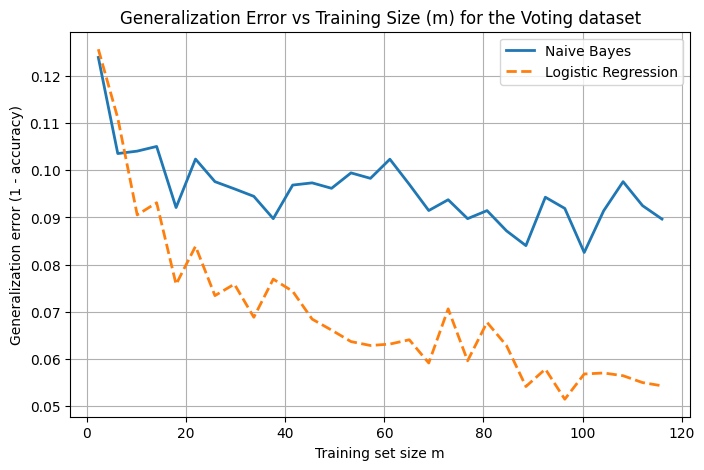

In [14]:
title = "Generalization Error vs Training Size (m) for the Voting dataset"
plot_learning_curves(m_values, scores_nbc, scores_lr, title)

# Interpretation:

# We see that the Naive Bayes Classifier reaches a low generalization error faster,
# however, for this dataset we see that we enter the 2nd regime very quickly,
# where the Logistic Regression model outperforms NBC by a large margin.
# These results are in line with our expectations (the results of the paper).

In [15]:
df_breast = pd.read_csv("breast-cancer.csv")

n_init = len(df_breast)
# drop NAN values
df_breast = df_breast.dropna()

n_final = len(df_breast)
print(f"Initial number of rows: {n_init}")
print(f"Number of rows dropped: {n_init - n_final}")
print(f"Final number of rows: {n_final}")

Initial number of rows: 286
Number of rows dropped: 0
Final number of rows: 286


In [16]:
df_breast

,Class,age,menopause,tumor-size,inv-nodes,node-caps,deg-malig,breast,breast-quad,irradiat
0,no-recurrence-events,30-39,premeno,30-34,0-2,no,3,left,left_low,no
1,no-recurrence-events,40-49,premeno,20-24,0-2,no,2,right,right_up,no
2,no-recurrence-events,40-49,premeno,20-24,0-2,no,2,left,left_low,no
3,no-recurrence-events,60-69,ge40,15-19,0-2,no,2,right,left_up,no
4,no-recurrence-events,40-49,premeno,0-4,0-2,no,2,right,right_low,no
...,...,...,...,...,...,...,...,...,...,...
281,recurrence-events,30-39,premeno,30-34,0-2,no,2,left,left_up,no
282,recurrence-events,30-39,premeno,20-24,0-2,no,3,left,left_up,yes
283,recurrence-events,60-69,ge40,20-24,0-2,no,1,right,left_up,no
284,recurrence-events,40-49,ge40,30-34,3-5,no,3,left,left_low,no


In [17]:
enc = LabelEncoder()
# fit a one-hot encoder and transform the labels
# (party is not ordinal)
y_cancer = enc.fit_transform(df_breast['Class'].to_numpy())

data_dummies = pd.get_dummies(
    df_breast, 
    # columns=['menopause', 'breast', 'irradiat', 'breast-quad'])
    columns=['menopause', 'irradiat', 'breast-quad'])

cols = ['inv-nodes', 'node-caps', 'deg-malig','tumor-size','age']
enc = OrdinalEncoder()
enc.set_output(transform="pandas")

X_ord_df = enc.fit_transform(df_breast[cols])

# Drop original ordinal cols from dummies DF if they are still there
data_dummies = data_dummies.drop(columns=cols)
# Drop 'breast' column since it is not needed, can be inferred from 'breast quad'
data_dummies = data_dummies.drop(columns=['breast'])

X_final = pd.concat([data_dummies, X_ord_df], axis=1)

X_final

,Class,menopause_ge40,menopause_lt40,menopause_premeno,irradiat_no,irradiat_yes,breast-quad_?,breast-quad_central,breast-quad_left_low,breast-quad_left_up,breast-quad_right_low,breast-quad_right_up,inv-nodes,node-caps,deg-malig,tumor-size,age
0,no-recurrence-events,False,False,True,True,False,False,False,True,False,False,False,0.0,1.0,2.0,5.0,1.0
1,no-recurrence-events,False,False,True,True,False,False,False,False,False,False,True,0.0,1.0,1.0,3.0,2.0
2,no-recurrence-events,False,False,True,True,False,False,False,True,False,False,False,0.0,1.0,1.0,3.0,2.0
3,no-recurrence-events,True,False,False,True,False,False,False,False,True,False,False,0.0,1.0,1.0,2.0,4.0
4,no-recurrence-events,False,False,True,True,False,False,False,False,False,True,False,0.0,1.0,1.0,0.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
281,recurrence-events,False,False,True,True,False,False,False,False,True,False,False,0.0,1.0,1.0,5.0,1.0
282,recurrence-events,False,False,True,False,True,False,False,False,True,False,False,0.0,1.0,2.0,3.0,1.0
283,recurrence-events,True,False,False,True,False,False,False,False,True,False,False,0.0,1.0,0.0,3.0,4.0
284,recurrence-events,True,False,False,True,False,False,False,True,False,False,False,4.0,1.0,2.0,5.0,2.0


In [18]:
X_train, X_test = train_test_split(X_final, test_size=0.8, random_state=42)

acc, f1, y_preds = evaluate_NB(
    MixedNaiveBayes,
    X_train,
    X_test,
    label_col='Class',
    alpha=2.0
)

print("NBC Accuracy:", acc)
print("NBC F1 Score:", f1)

# WITH breast column
# NBC Accuracy: 0.7249
# NBC F1 Score: 0.6208

# WITHOUT breast column
# NBC Accuracy: 0.7336
# NBC F1 Score: 0.6281


# Interpretation:

# In the end we decided to drop the breast column since it
# is not independent from the column 'breast quad',
# it can almost always be inferred from it, except for 1 case when 'breast quad' is 'central'.
# Empirical results also support this claim, showing that the model performs better without it


NBC Accuracy: 0.7336244541484717
NBC F1 Score: 0.6280586841334505


In [19]:
scores_nbc, scores_lr, m_values = run_learning_curve_experiment(
    X_final,
    'Class',
    0.5,
    model_nb_class= MixedNaiveBayes,
    runs_per_m=RUNS_PER_M,
    alpha = 1.0
)

print("NBC:\n", scores_nbc)
print("LR:\n", scores_lr)
print("Training sizes:", m_values)

1.0
NBC:
 [[0.50246479 0.46993848]
 [0.65197133 0.57179814]
 [0.62992701 0.56753443]
 [0.69107807 0.61093379]
 [0.67424242 0.60021847]
 [0.67683398 0.59711764]
 [0.70352941 0.62574396]
 [0.694      0.62154865]
 [0.69346939 0.61475829]
 [0.70583333 0.6226778 ]
 [0.71914894 0.64500857]
 [0.70826087 0.63420261]
 [0.70884956 0.63373635]
 [0.71040724 0.63769305]
 [0.71203704 0.64105316]
 [0.71753555 0.64963984]
 [0.71165049 0.62967189]
 [0.71840796 0.63861743]
 [0.72030457 0.64027464]
 [0.71875    0.64332044]
 [0.7171123  0.64003919]
 [0.71263736 0.64468959]
 [0.71299435 0.64460959]
 [0.71511628 0.6512666 ]
 [0.70178571 0.63150252]
 [0.7190184  0.65356644]
 [0.71772152 0.64540085]
 [0.70849673 0.63370443]
 [0.71013514 0.6376723 ]
 [0.71748252 0.64881466]]
LR:
 [[0.45140845 0.43867559]
 [0.61326165 0.56338565]
 [0.59708029 0.53775398]
 [0.61672862 0.55795625]
 [0.62386364 0.55824455]
 [0.64285714 0.56669787]
 [0.64941176 0.56993337]
 [0.6472     0.57835722]
 [0.64408163 0.56965841]
 [0.67666

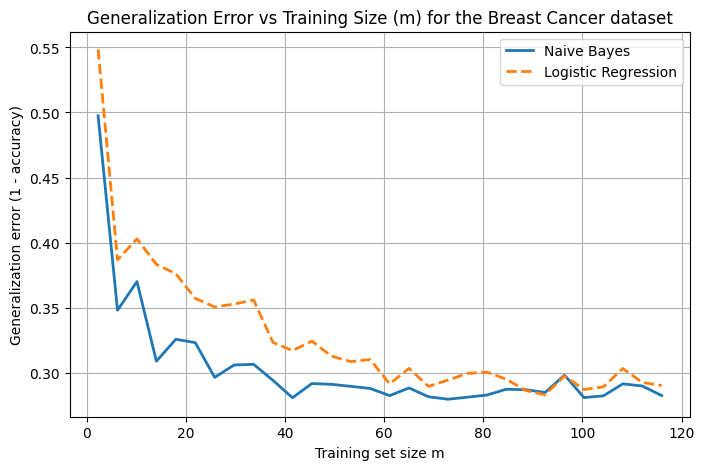

In [20]:
title = "Generalization Error vs Training Size (m) for the Breast Cancer dataset"
plot_learning_curves(m_values, scores_nbc, scores_lr, title)

# Interpretation:

# We can see again that the NBC model seems to be converging to its asymptotic error faster
# than the LR model, however the slope of the LR model is steeper, indicating that
# if we had more data, the LR model would probably reach a lower error than the NBC model.
# Therefore, these results are also in line with our expectations (the results of the paper).

#### Extra testing on the test datasets:


Initial number of rows: 231
Number of rows dropped: 0
Final number of rows: 231
NBC Accuracy: 0.9787234042553191
NBC F1 Score: 0.9777145566619251
1.0
NBC:
 [[0.87947598 0.87933698]
 [0.89644444 0.89628299]
 [0.90090498 0.90072143]
 [0.90046083 0.90020622]
 [0.90514019 0.90493467]
 [0.9052381  0.90505665]
 [0.90825243 0.90810444]
 [0.90693069 0.90677248]
 [0.90505051 0.90496113]
 [0.90876289 0.90857557]
 [0.90842105 0.90830674]
 [0.91129032 0.91104913]
 [0.90934066 0.90904623]
 [0.90280899 0.90253179]
 [0.90457143 0.90437038]
 [0.89883041 0.89860443]
 [0.90658683 0.90643428]
 [0.90613497 0.90597528]
 [0.90628931 0.9061175 ]
 [0.90645161 0.90633428]
 [0.90794702 0.90781699]
 [0.9047619  0.90451102]
 [0.91118881 0.91102279]
 [0.90647482 0.90628339]
 [0.91470588 0.91464356]
 [0.90909091 0.90893058]
 [0.9140625  0.9139004 ]
 [0.91451613 0.91435255]
 [0.90583333 0.90565874]
 [0.91551724 0.9153639 ]]
LR:
 [[0.88165939 0.88141633]
 [0.89377778 0.89323802]
 [0.91266968 0.91233031]
 [0.90506912 

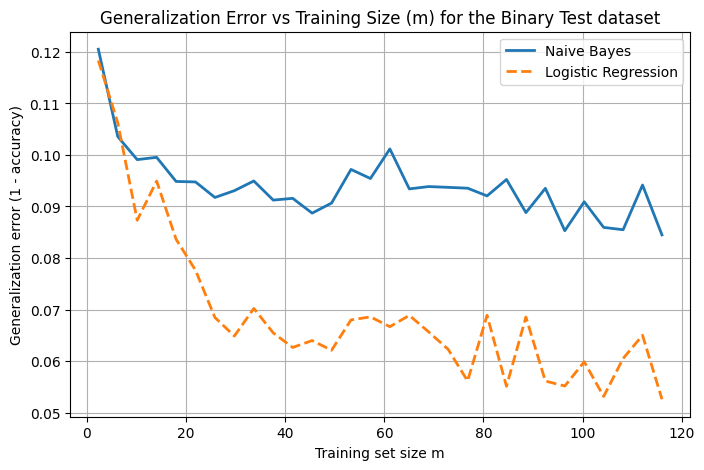

In [21]:
# first, the binary dataset:

df_binary = pd.read_csv("binary_test.csv")

n_init = len(df_binary)
# drop NAN values
df_binary = df_binary.dropna()

n_final = len(df_binary)
print(f"Initial number of rows: {n_init}")
print(f"Number of rows dropped: {n_init - n_final}")
print(f"Final number of rows: {n_final}")


X_train, X_test = train_test_split(df_binary, test_size=0.2, random_state=42)

acc, f1, y_preds = evaluate_NB(
    MixedNaiveBayes,
    X_train,
    X_test,
    label_col='0',
    alpha=2.0
)

print("NBC Accuracy:", acc)
print("NBC F1 Score:", f1)

scores_nbc, scores_lr, m_values = run_learning_curve_experiment(
    df_binary,
    '0',
    0.5,
    model_nb_class= MixedNaiveBayes,
    runs_per_m=RUNS_PER_M,
    alpha = 1.0
)

print("NBC:\n", scores_nbc)
print("LR:\n", scores_lr)
print("Training sizes:", m_values)

title = "Generalization Error vs Training Size (m) for the Binary Test dataset"
plot_learning_curves(m_values, scores_nbc, scores_lr, title)

# Interpretation

# We tested our NBC implementation on the binary_test dataset using the 
# run_learning_curve_experiment function. 
# On this dataset we also observe the same, correct behaviour for our function.


Initial number of rows: 286
Number of rows dropped: 0
Final number of rows: 286
NBC Accuracy: 0.5087719298245614
NBC F1 Score: 0.3948810850984764
1.0
NBC:
 [[0.42140078 0.30066035]
 [0.41818182 0.27684093]
 [0.41686747 0.29120232]
 [0.4322449  0.29823538]
 [0.40995851 0.27886384]
 [0.43248945 0.30448156]
 [0.42403433 0.29372878]
 [0.43318777 0.30319465]
 [0.42831858 0.29656719]
 [0.42972973 0.30215501]
 [0.41880734 0.29119051]
 [0.4182243  0.29747265]
 [0.43142857 0.30002828]
 [0.42912621 0.30097651]
 [0.42970297 0.29883222]
 [0.42929293 0.3006456 ]
 [0.42938144 0.29560994]
 [0.44315789 0.31287516]
 [0.43655914 0.30347175]
 [0.43351648 0.30898733]
 [0.4505618  0.31401937]
 [0.44597701 0.30736883]
 [0.44152047 0.30737093]
 [0.4497006  0.31133965]
 [0.44417178 0.30873618]
 [0.45031447 0.30879365]
 [0.44064516 0.30267157]
 [0.4384106  0.29887261]
 [0.43333333 0.29873992]
 [0.45664336 0.30794604]]
LR:
 [[0.38404669 0.28911766]
 [0.38814229 0.30774431]
 [0.38995984 0.29982595]
 [0.40081633 

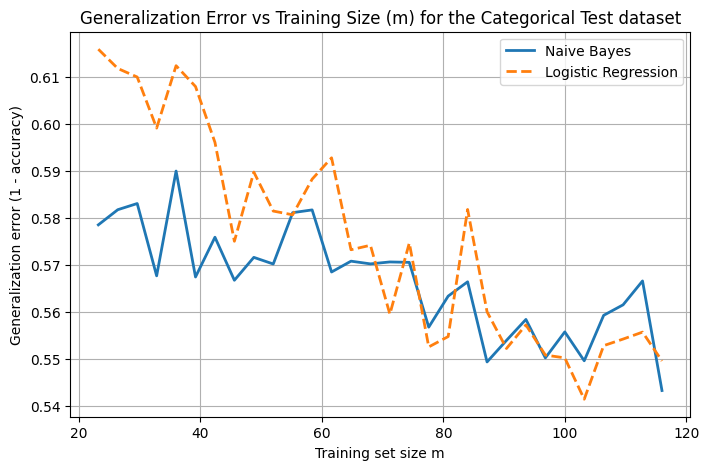

In [22]:
# then, the categorical dataset:
df_categorical = pd.read_csv("categorical_test.csv", header=None)

n_init = len(df_categorical)
# drop NAN values
df_categorical = df_categorical.dropna()

n_final = len(df_categorical)
print(f"Initial number of rows: {n_init}")
print(f"Number of rows dropped: {n_init - n_final}")
print(f"Final number of rows: {n_final}")


# Filter out class 0, cause there is only a single sample of it
df_categorical = df_categorical[df_categorical.iloc[:, 0] != 0]


X_train, X_test = train_test_split(df_categorical, test_size=0.2, random_state=42)


acc, f1, y_preds = evaluate_NB(
    MixedNaiveBayes,
    X_train,
    X_test,
    label_col=0,
    alpha=2.0
)

print("NBC Accuracy:", acc)
print("NBC F1 Score:", f1)

scores_nbc, scores_lr, m_values = run_learning_curve_experiment(
    df_categorical,
    0,
    0.5,
    model_nb_class= MixedNaiveBayes,
    runs_per_m=RUNS_PER_M,
    alpha = 1.0,
    start_space = 0.1,
    end_space = 30,
    max_iter = 3000,
)

print("NBC:\n", scores_nbc)
print("LR:\n", scores_lr)
print("Training sizes:", m_values)

title = "Generalization Error vs Training Size (m) for the Categorical Test dataset"
plot_learning_curves(m_values, scores_nbc, scores_lr, title)

# Interpretation

# We tested our NBC implementation on the categorical_test dataset as well,
# using the run_learning_curve_experiment function. 
# On this dataset we also observe the same, correct behaviour for our function.
